# 3.  Star Catalogues

In this tutorial we show how you can create a custom star catalogue. Creating such synthetic star catalogues can be done in multile ways, which will be the main topic of this tutorial, however, we also show how you directly can use the *default* input catalogue of the LOP South field from the PLATO Input Catalogue (PIC1.1). To create custom sub-PIC catalgues we recommend to have a look at PlatoSim's built-in simulations tool called `picsim` presented in the last section.

### Setup notebook

In [1]:
# Alow changes to the PlatoSim code outside this notebook
%load_ext autoreload
%autoreload 2

# To interact with the plot use
%matplotlib notebook

### Imports

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# PlatoSim
import platosim.plot            as pt
import platosim.utilities       as ut
import platosim.referenceFrames as rf
from platosim.simulation   import Simulation
from platosim.simfile      import SimFile
from platosim.matplotlibrc import setup_notebook
setup_notebook()

In [3]:
# Select output directory of simulations 
outputDir = os.getcwd()

---
## 3.1 - Create a star catalogue for a *custom subfield*
---

As a first example we show how to create a small custom stellar catalogue prior to running PlatoSim. As always we first define the inputs and outputs:

In [4]:
# Set up a Simulation object
sim = Simulation("output_example1", outputDir=outputDir)

You can also cutomize the orientation (pointing and rotation) of the platform before defining your stellar catalogue:

In [5]:
sim["Platform/Orientation/Angles/RAPointing"]            = 180.0 
sim["Platform/Orientation/Angles/DecPointing"]           = -70.0
sim["Platform/Orientation/Angles/SolarPanelOrientation"] = 0.0

We then set a subfield around the stars being large enough to contain all of them ($50\times50$ pixels):

In [6]:
sim["SubField/ZeroPointRow"]    = 3000
sim["SubField/ZeroPointColumn"] = 3000
sim["SubField/NumColumns"]      = 50
sim["SubField/NumRows"]         = 50

Specify the pixel coordinates (of the CCD, not of the subfield) of your stars, and create the star catalog file: an ascii file will be written with the columns: `ra`, `dec`, `mag`, and `ID`. We will use the above defined CCD location to set the rows and columns of the stars:

In [7]:
# Define catalogue
row = np.array([ 7.0, 40.0, 20.0]) + sim["SubField/ZeroPointRow"]
col = np.array([30.0, 45.0,  5.0]) + sim["SubField/ZeroPointColumn"]
mag = np.array([11.0, 10.0, 12.0])
ID  = [0, 1, 2]

# Automatic catalogue file creation
starcatFile = outputDir + "/starcat_example1.txt"
sim.createStarCatalogFileFromPixelCoordinates(row, col, mag, ID, starcatFile)

# Load star catalogue into a Pandas array to visualise it
pd.read_csv(starcatFile, sep=' ', skiprows=1, names=['RA', 'Dec', 'Mag', 'ID'])

,RA,Dec,Mag,ID
0,158.650414,-56.068100,11.0,0
1,158.478901,-55.982673,10.0,1
2,158.505402,-56.140009,12.0,2


Note that `createStarCatalogFileFromPixelCoordinates()` automatically sets the path to the newly created stellar catalogue file. If you need to tell PlatoSim to point to a different file simply use:

In [8]:
# Make sure the simulation object uses this star catalog
sim["ObservingParameters/StarCatalogFile"] = starcatFile

Finally let's run the simulation and show the stellar pixel map:

In [9]:
simfile = sim.run(removeOutputFile=True)

<IPython.core.display.Javascript object>


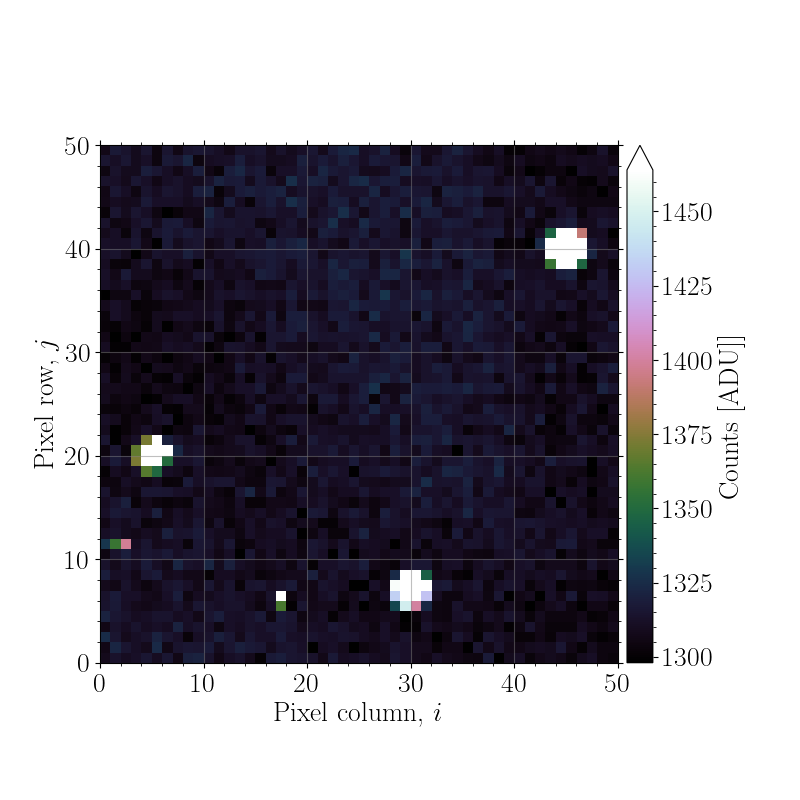

interactive(children=(IntSlider(value=0, description='Image:', layout=Layout(width='70%'), max=9), Output()), …

In [10]:
fig, ax = simfile.showImage(imgScale="percentile", clip=1,  fontSize=20, 
                            colorMap="cubehelix", colorBar=True, showGrid=True);

Congratulation you have now created your first stellar catalogue and it to run a simulation! Above we have created a star catalogue from a set of custom pixel coordinates, however, it is of course also possible to directly do this from the equatorial sky coordinates. This can be done using the function `createStarCatalogFile()` as will be done later.

---
## 3.2 - Star catalogue with the *Distribution* class
---

With the above definitions we can start simulting a realistic synthetic stellar catalogue. For this purpose we have created a `Distribution` class which, among others, can be used to generate synthetic stellar catalogues. Let's display the class functions:

In [11]:
from platosim.distribution import Distribution
ut.getFunctions(Distribution)

Distribution functions
__del__
__init__
expFunction
getMagnitudeDistribution
getRandomMagnitude
getRandomPosition
getStarCatalog
inverseExpFunction
readMagnitudes


As always we start fetching a simulation object to generate a new simulation before we start modifying the object:

In [12]:
sim = Simulation("output_example2", outputDir=outputDir)

To create an instance of `Distribution` class object we need to feed it with a stellar catalogue. Here we use the PlatoSim's default PIC1.1 catalogue of the LOP South:

In [13]:
filename = os.getenv("PLATO_PROJECT_HOME") + "/inputfiles/starcatalog.txt"
dist = Distribution(filename)

First we can use `getStarCatalog()` to generate a random catalogue. Note that in this example we simply use the CCD origin $(0,0)$ as a zero-point for the subfield row and column. Hence:

<IPython.core.display.Javascript object>


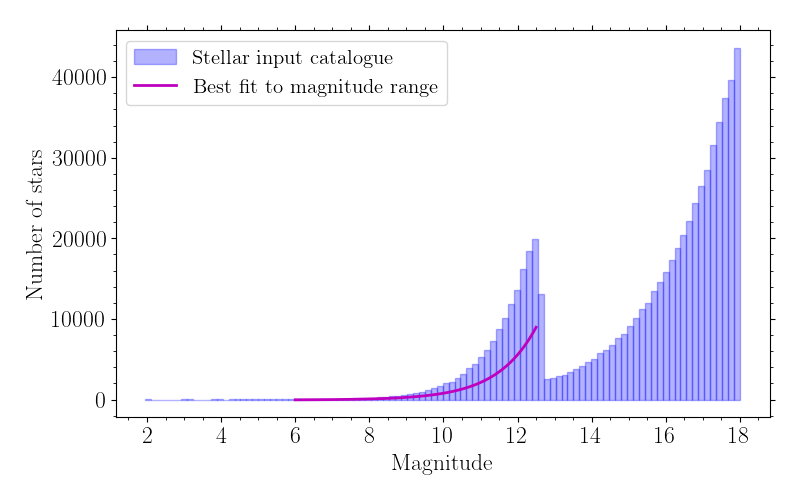

In [14]:
row, col, mag, ID = dist.getStarCatalog(numStars=50, minMag=6, maxMag=12.5, 
                                        subfieldNumRows=sim["SubField/NumRows"],
                                        subfieldNumCols=sim["SubField/NumColumns"], 
                                        subfieldZeroRow=sim["SubField/ZeroPointRow"],
                                        subfieldZeroCol=sim["SubField/ZeroPointColumn"],
                                        plot=True)

In [15]:
# Automatic catalogue file creation
starcatFile = outputDir + "/starcat_example2.txt"
sim.createStarCatalogFileFromPixelCoordinates(row, col, mag, ID, starcatFile)

In [16]:
# Run simulation
simfile = sim.run(removeOutputFile=True)

<IPython.core.display.Javascript object>


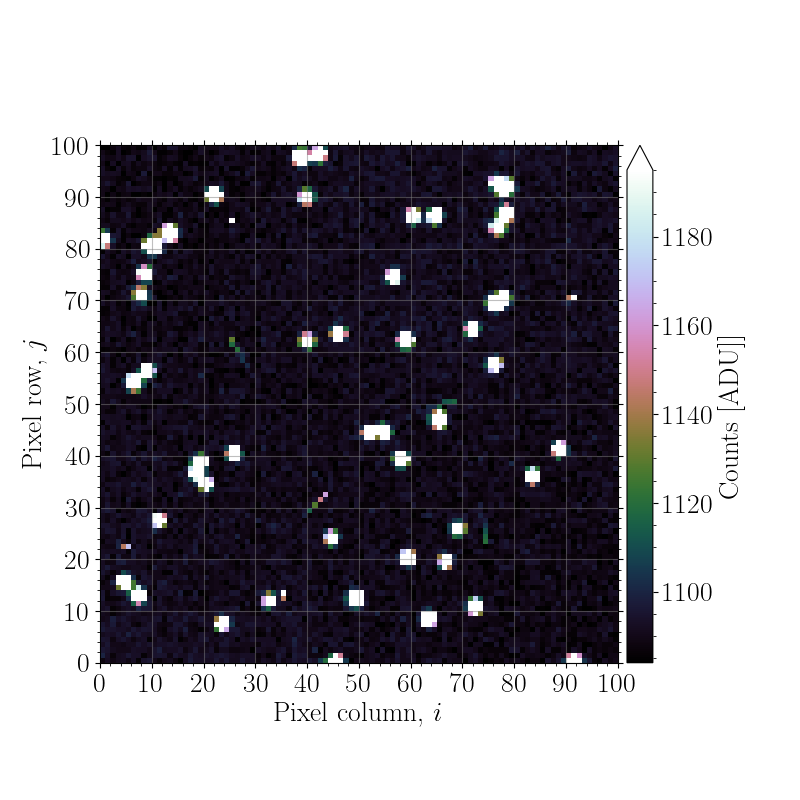

interactive(children=(IntSlider(value=0, description='Image:', layout=Layout(width='70%'), max=9), Output()), …

In [17]:
# Plot the subfield
fig, ax = simfile.showImage(imageNr=False, imgScale="percentile", clip=3,  
                            figsize=(8,8), fontSize=20, useTitle=False,
                            showStarPositions=False, showStarIDs=False,
                            colorMap="cubehelix", colorBar=True, showGrid=True);

You can create a stellar catalogue given any stellar input distribution, however, the catalogue fed to `Distribution` needs to be an ascii file with the appropiate columns of a PlatoSim catalogue (as has been shown above). Note that since the PIC used above consist of pre-selected targets of the PLATO mission it is obviously biased in its distribution of stellar magnitudes (which is clear from the two different "samples" that seperates bright (P1) stars from faint (P5) stars).

---
## 3.3 - Star catalogues with *referenceFrames()* utilities
---

Instead of generating a random star catalogue, it is also possible to place one or more stars within the subfield, by specifying their CCD coordinates instead of equatorial coordinates (RA, Dec). This is especially useful when you want to test features at a specific location on the CCD or if you want to supply a grid/pattern of stars equally distributed over the PLATO CCDs. Methods that we will focus on are:

* `pixelToSkyCoordinates()`
* `skyToPixelCoordinates()`

These are convenience methods that combine the above steps in one simple function and take field distortion into account.

#### Use *pixelToSkyCoordinates()* together with *setSubfieldAroundSkyCoordinates()*

First we create a new simulation object and set the platform orientation:

In [18]:
sim = Simulation("output_example31", outputDir=outputDir)

Below we select the location and size of the subfield on the CCD and use `pixelToSkyCoordinates()` to calculate equatorial sky coordinate of the central subfield location:

In [19]:
# Select CCD and subfield
ccdCode       = '2'
xCCDpixel     = 300 
yCCDpixel     = 300
subfieldSizeX = 100
subfieldSizeY = 100

In [20]:
raCenter, decCenter = rf.pixelToSkyCoordinates(sim, ccdCode, xCCDpixel, yCCDpixel)
print(f'Subfield center (RA, Dec) = ({np.rad2deg(raCenter)}, {np.rad2deg(decCenter)})')

Subfield center (RA, Dec) = (84.5255655818763, -63.23132961127556)


We can now use `setSubfieldAroundSkyCoordinates()` to place the subfield given a set of equatorial sky coordinates (RA, Dec). Note that if the subfield falls outside the camera FOV or do not fall on any of the four CCDs, then this function will return `False`. Let's place the subfield, run the simulation, and lastly visualise the result:

In [21]:
sim.setSubfieldAroundSkyCoordinates(raCenter, decCenter, subfieldSizeX, subfieldSizeY, normal=True)

True

And finally let's run and plot the simulation:

In [22]:
simfile = sim.run(removeOutputFile=True)

<IPython.core.display.Javascript object>


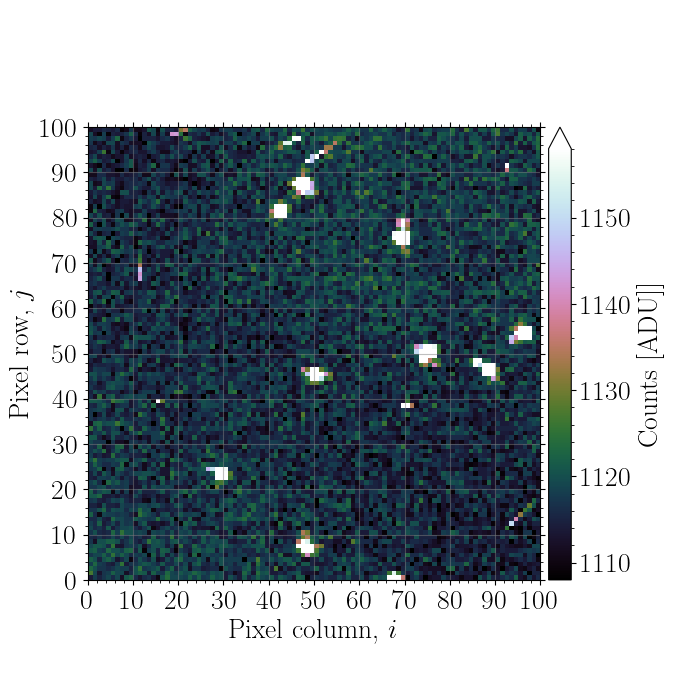

interactive(children=(IntSlider(value=0, description='Image:', layout=Layout(width='70%'), max=9), Output()), …

In [23]:
fig, ax = simfile.showImage(imageNr=False, imgScale="percentile", clip=1,  
                            figsize=(7,7), fontSize=20, useTitle=False,
                            showStarPositions=False, showStarIDs=False,
                            colorMap="cubehelix", colorBar=True, showGrid=True);

#### Use *skyToPixelCoordinates()* together with *setSubfieldAroundPixelCoordinates()*

Again first create a new simulation object:

In [24]:
sim = Simulation("output_example32", outputDir=outputDir)

The approach now is to do the inverse reference frame transformations, going from the equatorial sky coordinate to the CCD focal plane pixel coordinate of a subfield's central location. While using the sky coordinates of the subfield center from above, this can be done using the function `skyToPixelCoordinates()` as follows:

In [25]:
ccdCode, xCCDpixel, yCCDpixel = rf.skyToPixelCoordinates(sim, raCenter, decCenter, normal=True)

# Just as a sanity check let's display the pixel coordinates
print(f'CCDcode: {ccdCode}, Column: {xCCDpixel}, Row: {yCCDpixel}')

CCDcode: 2, Column: 299.97269650091596, Row: 299.979808858178


We now use the funciton `setSubfieldAroundPixelCoordinates()` to set the subfield around the pixel coordinates:

In [26]:
sim.setSubfieldAroundPixelCoordinates(ccdCode, xCCDpixel, yCCDpixel, subfieldSizeX, subfieldSizeY)

True

Lastly, let's run and plot the simulation:

In [27]:
simfile = sim.run(removeOutputFile=True)

<IPython.core.display.Javascript object>


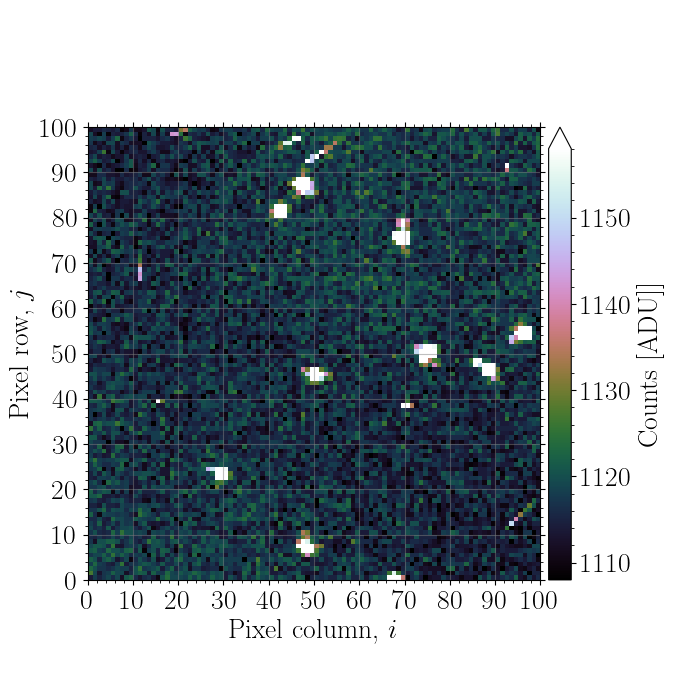

interactive(children=(IntSlider(value=0, description='Image:', layout=Layout(width='70%'), max=9), Output()), …

In [28]:
fig, ax = simfile.showImage(imageNr=False,  imgScale="percentile", clip=1,  
                            figsize=(7,7), fontSize=20, useTitle=False,
                            showStarPositions=False, showStarIDs=False,
                            colorMap="cubehelix", colorBar=True, showGrid=True);

---
## 3.4 - Star catalogue with a custom spatial configuration
---

As an example we create a catalogue with stars of identical magnitude lying over the diagonals of the choosen CCD:

In [29]:
sim = Simulation("output_example4", outputDir=outputDir)

In the following we will create a new star catalogue and thus we can choose any platform orientation:

In [30]:
sim["Platform/Orientation/Angles/RAPointing"]              = 40.0
sim["Platform/Orientation/Angles/DecPointing"]             = 40.0
sim["Platform/Orientation/Angles/SolarPanelOrientation"]   = 0.0

In [31]:
# Generate star catalogue
starCatalogFilename = outputDir + "/starcat_example4.txt"
ccdCode  = '2'
magStars = []
raStars  = []
decStars = []

for x in range(255, 4510, 200):
    ra, dec = rf.pixelToSkyCoordinates(sim, ccdCode, x, x) 
    raStars.append(ra)
    decStars.append(dec)
    magStars.append(12.5)
    
for x in range(255, 4510, 200):
    ra, dec = rf.pixelToSkyCoordinates(sim, ccdCode, x, 4510 - x)
    raStars.append(ra)
    decStars.append(dec)
    magStars.append(12.5)

raStars  = np.array(raStars)
decStars = np.array(decStars)
magStars = np.array(magStars)

raStars[raStars > np.pi] = raStars[raStars > np.pi] - 2 * np.pi

Nstars   = len(raStars)
raStars  = np.rad2deg(raStars)
decStars = np.rad2deg(decStars)
starIDs  = np.arange(Nstars) + 1

Create the stellar catalogue file and set the path automatically in the YAML tree:

In [32]:
sim.createStarCatalogFile(raStars, decStars, magStars, starIDs, starCatalogFilename)

First let's check catalogue by plotting the stars and the CCDs in a Mollweide sky projection in equatorial coordinates:

In [33]:
alpha = np.deg2rad(float(sim["Platform/Orientation/Angles/RAPointing"]))
delta = np.deg2rad(float(sim["Platform/Orientation/Angles/DecPointing"]))
kappa = np.deg2rad(float(sim["Platform/Orientation/Angles/SolarPanelOrientation"]))

In [34]:
azimuth = np.deg2rad(float(sim["Telescope/AzimuthAngle"]))
tilt    = np.deg2rad(float(sim["Telescope/TiltAngle"]))

In [35]:
focalPlaneAngle = np.deg2rad(float(sim["Camera/FocalPlaneOrientation/ConstantValue"]))  # [rad]
focalLength     = float(sim["Camera/FocalLength/ConstantValue"])*1000.                  # [m] -> [mm]
pixelSize       = float(sim["CCD/PixelSize"])                                           # [micron]

<IPython.core.display.Javascript object>


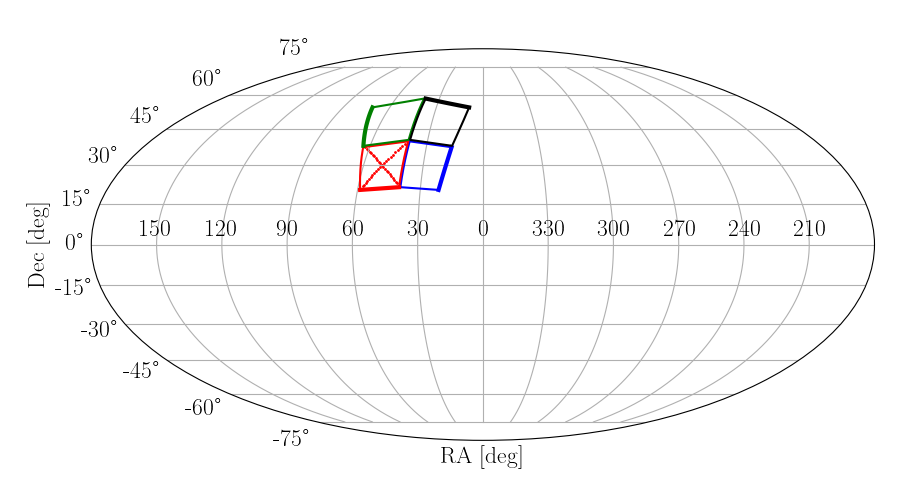

In [36]:
fig, ax = pt.drawCCDsInSkyMollweide(alpha, delta, kappa, tilt, azimuth, focalPlaneAngle, focalLength, pixelSize)
ax.scatter(-np.deg2rad(raStars), np.deg2rad(decStars), s=1, color='r');

Similarly we can also show the stars in the CCD focal plane (note that the optical axis in the plot above points towards the reader):

<IPython.core.display.Javascript object>


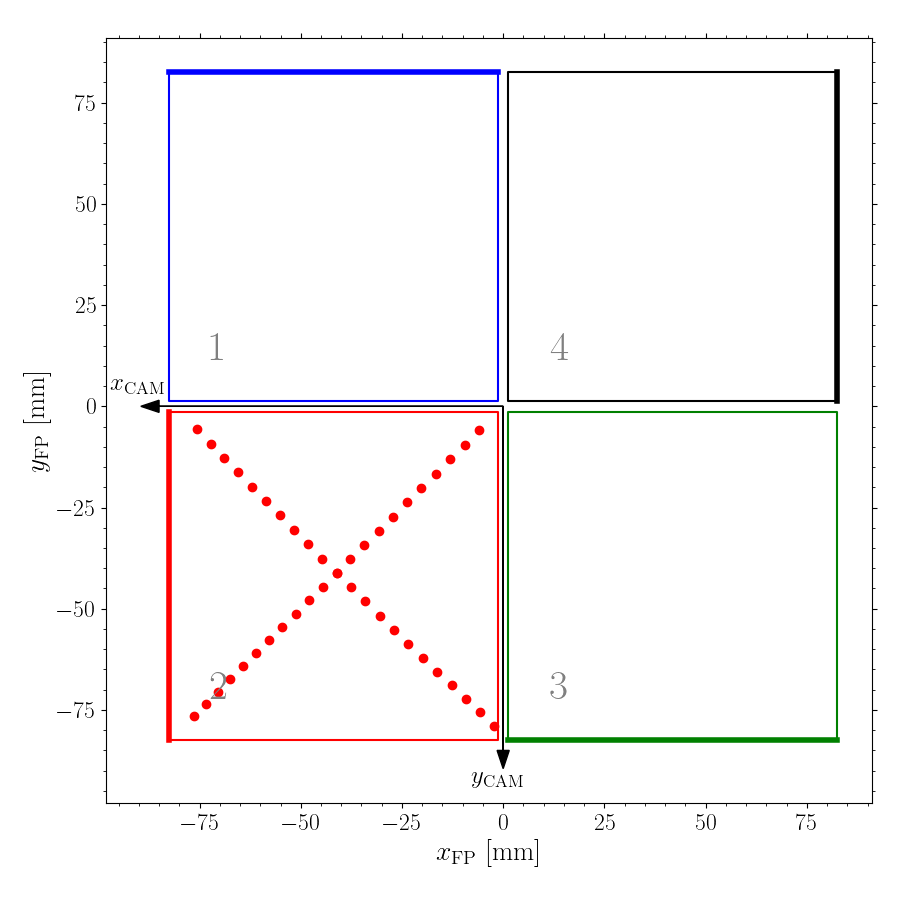

In [37]:
# Draw the CCD squares, with the readout register as a thicker line
pt.drawCCDsInFocalPlane(pixelSize, plotCCDlabels=True, normal=True)

# Draw the stars on the CCD
for i in range(0, Nstars):
    pt.drawStarInFocalPlane(sim, np.deg2rad(raStars[i]), np.deg2rad(decStars[i]))

# Plot the X axis of the telescope reference frame in this focal plane
(xTL, yTL, zTL) = (0.5, 0.0, np.sqrt(1-0.5**2))           # unit vector
xFP, yFP = rf.telescopeToUndistortedFocalPlaneCoordinates(xTL, yTL, zTL, focalLength, focalPlaneAngle)
length = np.sqrt(xFP**2+yFP**2)
xFP *= 85.0 / length
yFP *= 85.0 / length
plt.arrow(0.0, 0.0, xFP, yFP, head_width=3, color="k")
plt.text(xFP-12, yFP+4, r"$x_{\rm CAM}$", fontsize=18, color="k")

# Plot the Y axis of the telescope reference frame in this focal plane
(xTL, yTL, zTL) = (0.0, 0.5, np.sqrt(1-0.5**2))          # unit vector
xFP, yFP = rf.telescopeToUndistortedFocalPlaneCoordinates(xTL, yTL, zTL, focalLength, focalPlaneAngle)
length = np.sqrt(xFP**2+yFP**2)
xFP *= 85.0 / length
yFP *= 85.0 / length
plt.arrow(0.0, 0.0, xFP, yFP, head_width=3, color="k")
plt.text(xFP-8, yFP-8, r"$y_{\rm CAM}$", fontsize=18, color="k")

plt.axis('scaled')
plt.tight_layout();

---
## 3.5 - Generate custom sub-PIC catalogues
---

Before we end this tutorial we note that it is also possible to use the script `picsim` to generate a custom stellar catalogue by randomly drawing stars from the PLATO Input Catalogue (PIC). You can use the script `picsim` which can be called from the command like:

    picsim -h
    
How to use this script is presented in our [Online Documentation](http://ivs-kuleuven.github.io/PlatoSim3/platonium_tutorials.html). Note that the output files are in `feather` format which Pandas can read extremely fast. The output files from `picsim` are specifically tailored to run simulations with the script `platonium` (also presented in the online documentation).